# Тема
### **Построение нейросетевого классификатора для идентификации типа подстилающей поверхности при движении мобильного робота в условиях неоднородной среды**

Студент: **Массунда Жуниор Фернандо**

Группа: **8ЕМ51**

Вариант: **15** 
- Тип поверхности: **5**
- Использование переменных: **{V1, V2}**

# Цель работы
1. Приобретение практических навыков в решении одной из актуальных задач в построении интеллектуальной СУ автономной робототехнической системы, функционирующей в условиях физически неоднородной среды;
2. Практическое изучение особенностей и способов решения задачи несбалансированной
классификации, а также расширение инструментария разработчика в части работы с методами
машинного обучения;
3. Развитие исследовательских навыков работы с методом машинного обучения на примере прикладной задачи и реальной выборке данных;
4. Развитие навыков программирования систем вычислительного интеллекта на Python.

## Задачи
1. Построить нейросетевой классификатор (в соответствии с вариантом задания), протестированный и более-менее устойчивый к новым данным (самостоятельно осуществить проверку на выборке С); 
2. Приобрести опыт и понимание работы нейросетевого алгоритма в части влияния различных его параметров (числа слоев, нейронов в слое, числа итераций, функции активации, способа предобработки данных и т.п.) на качество получаемой модели.

# Ход работы

# **1. Импортирование библиотек**

In [46]:
# Импорт основных библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Импорт из sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Импорт наших функций из utils.py
import sys
import os

# Добавляем путь к папке src
current_dir = os.getcwd()
src_path = os.path.join(current_dir, '../Source')
sys.path.append(src_path)

print(f"Текущая директория: {current_dir}")
print(f"Путь к src: {src_path}")

try:
    from Utils_A import prepare_data_v1, prepare_data_v2, prepare_data_v1v2, calculate_v2_features, evaluate_model, plot_training_results, plot_test_results, V1_COLUMNS, V2_COLUMNS
    print("✓ Все библиотеки и функции успешно импортированы")
    print(f"✓ Используем признаки V1: {len(V1_COLUMNS)} признаков")
    print(f"✓ Используем признаки V2: {len(V2_COLUMNS)} признаков")
except ImportError as e:
    print(f"✗ Ошибка импорта: {e}")
    print("Проверьте, что файл utils.py находится в папке src/")
    print("Содержимое папки src:", os.listdir(src_path) if os.path.exists(src_path) else "Папка не существует")

#from Source.Utils_1 import V1_COLUMNS, V2_COLUMNS, calculate_v2_features, load_dataset, prepare_data, dataset_info, evaluate_model, test_model, plot_training_results, plot_test_results

Текущая директория: d:\HereAgain\CALOIRO 2025\Programming\LAB_MAI_02\Report
Путь к src: d:\HereAgain\CALOIRO 2025\Programming\LAB_MAI_02\Report\../Source
✓ Все библиотеки и функции успешно импортированы
✓ Используем признаки V1: 15 признаков
✓ Используем признаки V2: 7 признаков


# **2. Загрузка и анализ данных**
- Тип поверхности: 5  
- Признаки: V1 и V2


БЛОК 2: ЗАГРУЗКА И АНАЛИЗ ДАННЫХ
✓ Данные загружены из: ..\Data\Data_Set_(A+B).xlsx
✓ Данные загружены: 176 строк, 16 столбцов
  Столбцы: ['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 'V1real', 'V2real', 'V3real', 'N1', 'N2', 'N3', 'Type']
✓ Новые данные загружены: 176 строк, 23 столбцов
  Столбцы: ['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 'V1real', 'V2real', 'V3real', 'N1', 'N2', 'N3', 'Type', 'Vx', 'Vy', 'Omega', 'Ix', 'Iy', 'Iphi', 'Isum']

ПЕРВЫЕ 5 СТРОК ДАННЫХ:
         I1        I2        I3        gx        gy        gz        ax  \
0  1.126697  0.021116  0.927601  0.712941 -0.252941  1.081765  0.043529   
1  1.039215  0.015083  0.953243  0.229412  0.276471  0.485294  0.013672   
2  0.911011  0.004525  0.947210  1.170588  0.222941  0.664118  0.011704   
3  0.692308  1.156862  0.550528  1.165294  0.698235 -3.421765  0.001321   
4  0.529412  1.024133  0.453997  0.808235  0.090000 -1.449412  0.006218   

         ay        az      V1real  ...    N2    N3  Typ

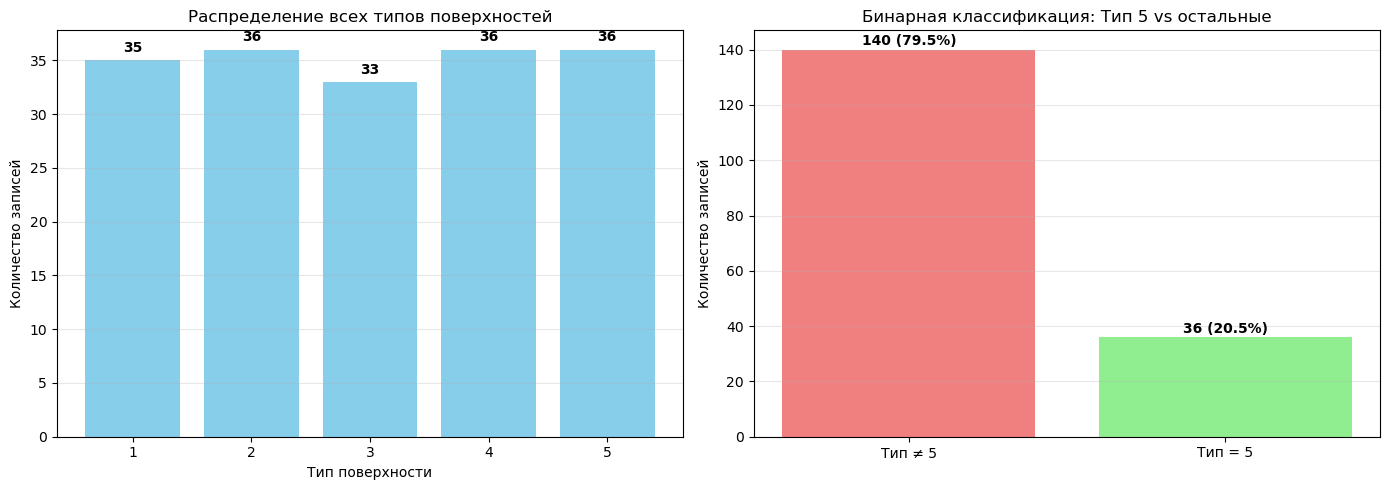


ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ О ПРИЗНАКАХ:

Диапазоны значений признаков V1:
  N1: [-5519.00, 14770.00]
  N2: [-8010.00, 14829.00]
  N3: [-72.00, 14554.00]
  V1real: [-300.60, 772.20]
  V2real: [-363.60, 768.60]

Проверка пропущенных значений:
  ✓ Нет пропущенных значений

Диапазоны значений признаков V2:
  Vx: [-534.46, 14341.38]
  Vy: [-336.00, 14832.00]
  Omega: [-7.49, 247.30]
  Ix: [-0.20, 0.38]
  Iy: [-0.36, 0.80]

Проверка пропущенных значений:
  ✓ Нет пропущенных значений

Диапазоны значений признаков V1 + V2:
  N1: [-5519.00, 14770.00]
  N2: [-8010.00, 14829.00]
  N3: [-72.00, 14554.00]
  V1real: [-300.60, 772.20]
  V2real: [-363.60, 768.60]

Проверка пропущенных значений:
  ✓ Нет пропущенных значений

БЛОК 2 ЗАВЕРШЕН ✓


In [47]:
# ---------- БЛОК 2: ЗАГРУЗКА И АНАЛИЗ ДАННЫХ ----------
print("\n" + "="*70)
print("БЛОК 2: ЗАГРУЗКА И АНАЛИЗ ДАННЫХ")
print("="*70)

# Загрузка обучающих данных
from pathlib import Path

try:
    # Пробуем разные пути
    data_paths = [
        Path('../Data/Data_Set_(A+B).xlsx'),
        Path('Data/Data_Set_(A+B).xlsx'),
        Path(r'D:\HereAgain\CALOIRO 2025\Programming\LAB_MAI_02\Data\Data_Set_(A+B).xlsx')
    ]
    
    data = None
    loaded_path = None
    for path in data_paths:
        if path.exists():
            data = pd.read_excel(path)
            loaded_path = path
            print(f"✓ Данные загружены из: {path}")
            break
    
    if data is None:
        print("✗ Файл данных не найден!")
        print("Проверьте, что Data_Set_(A+B).xlsx находится в папке data/")
        print("Проверяемые пути:")
        for path in data_paths:
            print(f"  - {path} ({'Существует' if path.exists() else 'Не существует'})")
    else:
        print(f"✓ Данные загружены: {data.shape[0]} строк, {data.shape[1]} столбцов")
        print(f"  Столбцы: {list(data.columns)}")
        
        # Добавляем переменные V2 к общей Dataframe
        data = calculate_v2_features(data)
        print(f"✓ Новые данные загружены: {data.shape[0]} строк, {data.shape[1]} столбцов")
        print(f"  Столбцы: {list(data.columns)}")
        
        # Показываем первые 5 строк данных
        print("\n" + "="*50)
        print("ПЕРВЫЕ 5 СТРОК ДАННЫХ:")
        print("="*50)
        print(data.head())
        
        # Показываем последние 5 строк данных
        print("\n" + "="*50)
        print("ПОСЛЕДНИЕ 5 СТРОК ДАННЫХ:")
        print("="*50)
        print(data.tail())
        
        # Основные статистики по числовым признакам
        print("\n" + "="*50)
        print("ОСНОВНЫЕ СТАТИСТИКИ ПО ПРИЗНАКАМ:")
        print("="*50)
        print(data.describe())
        
except Exception as e:
    print(f"✗ Ошибка загрузки данных: {e}")
    import traceback
    traceback.print_exc()

# Анализ распределения типов поверхностей
if data is not None:
    print("\n" + "="*50)
    print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ ТИПОВ ПОВЕРХНОСТЕЙ:")
    print("="*50)
    
    type_counts = data['Type'].value_counts().sort_index()
    print("\nКоличество записей по типам поверхностей:")
    for type_num, count in type_counts.items():
        print(f"  Тип {type_num}: {count} записей ({count/data.shape[0]:.1%})")
    
    # Табличное представление
    print("\nТаблица распределения:")
    type_df = pd.DataFrame({
        'Тип': type_counts.index,
        'Количество': type_counts.values,
        'Доля': (type_counts.values / data.shape[0] * 100).round(1)
    })
    print(type_df.to_string(index=False))

    # Подготовка данных для типа поверхности 5
    print("\n" + "="*50)
    print("ПОДГОТОВКА ДАННЫХ ДЛЯ КЛАССИФИКАЦИИ:")
    print("="*50)
    
    print("Подготовка данных для классификации типа поверхности 5...")
    
    X_v1, y_v1 = prepare_data_v1(data, target_type=5)
    
    X_v2, y_v2 = prepare_data_v2(data, target_type=5)
    
    X_v1v2, y_v1v2 = prepare_data_v1v2(data, target_type=5)

    X, y = X_v1v2, y_v1v2
    
    # Показываем первые 5 строк признаков
    
    # V1
    print(f"✓ Признаки X_v1: {X_v1.shape[0]} samples × {X_v1.shape[1]} features")
    print(f"✓ Целевая переменная y_v1: {y_v1.sum()} класса 1 ({y_v1.mean():.1%}), {len(y_v1)-y_v1.sum()} класса 0")
    
    print("\nПервые 5 строк признаков X_v1:")
    print(X_v1.head())
    print("\nПервые 10 значений целевой переменной y_v1:")
    print(y_v1.head(10).values)
    
    # V2
    print(f"✓ Признаки X_v2: {X_v2.shape[0]} samples × {X_v2.shape[1]} features")
    print(f"✓ Целевая переменная y_v2: {y_v2.sum()} класса 1 ({y_v2.mean():.1%}), {len(y_v2)-y_v2.sum()} класса 0")
    
    print("\nПервые 5 строк признаков X_v2:")
    print(X_v2.head())
    print("\nПервые 10 значений целевой переменной y_V2:")
    print(y_v2.head(10).values)
    
    # V1 + V2
    print(f"✓ Признаки X_v1v2: {X_v1v2.shape[0]} samples × {X_v1v2.shape[1]} features")
    print(f"✓ Целевая переменная y_v1v2: {y_v1v2.sum()} класса 1 ({y_v1v2.mean():.1%}), {len(y_v1v2)-y_v1v2.sum()} класса 0")
    
    print("\nПервые 5 строк признаков X_v1v2:")
    print(X_v1v2.head())
    print("\nПервые 10 значений целевой переменной y_v1v2:")
    print(y_v1v2.head(10).values)
    
       # Визуализация распределения классов
    print("\n" + "="*50)
    print("ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КЛАССОВ:")
    print("="*50)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Все типы
    bars1 = axes[0].bar(type_counts.index, type_counts.values, color='skyblue')
    axes[0].set_xlabel('Тип поверхности')
    axes[0].set_ylabel('Количество записей')
    axes[0].set_title('Распределение всех типов поверхностей')
    axes[0].set_xticks(type_counts.index)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на столбцы
    for bar, count in zip(bars1, type_counts.values):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    str(count), ha='center', va='bottom', fontweight='bold')

    # Бинарная классификация (тип 5 vs остальные)
    class_counts = y_v1.value_counts()
    bars2 = axes[1].bar(['Тип ≠ 5', 'Тип = 5'], class_counts.values, 
                       color=['lightcoral', 'lightgreen'])
    axes[1].set_ylabel('Количество записей')
    axes[1].set_title('Бинарная классификация: Тип 5 vs остальные')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на столбцы
    for i, (bar, count) in enumerate(zip(bars2, class_counts.values)):
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f"{count} ({class_counts.values[i]/len(y_v1):.1%})", 
                    ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()
    
    # Дополнительная информация о признаках
    print("\n" + "="*50)
    print("ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ О ПРИЗНАКАХ:")
    print("="*50)
    
    # V1
    print(f"\nДиапазоны значений признаков V1:")
    for col in X_v1.columns[:5]:  # Показываем первые 5 признаков
        print(f"  {col}: [{X_v1[col].min():.2f}, {X_v1[col].max():.2f}]")
    
    print("\nПроверка пропущенных значений:")
    missing = X_v1.isnull().sum()
    if missing.sum() == 0:
        print("  ✓ Нет пропущенных значений")
    else:
        print(f"  ✗_v1 Есть пропущенные значения: {missing.sum()}")
        for col, count in missing[missing > 0].items():
            print(f"    - {col}: {count} пропусков")
            
    
    # V2
    print(f"\nДиапазоны значений признаков V2:")
    for col in X_v2.columns[:5]:  # Показываем первые 5 признаков
        print(f"  {col}: [{X_v2[col].min():.2f}, {X_v2[col].max():.2f}]")
    
    print("\nПроверка пропущенных значений:")
    missing = X_v2.isnull().sum()
    if missing.sum() == 0:
        print("  ✓ Нет пропущенных значений")
    else:
        print(f"  ✗_v2 Есть пропущенные значения: {missing.sum()}")
        for col, count in missing[missing > 0].items():
            print(f"    - {col}: {count} пропусков")
            
    # V1 + V2
    print(f"\nДиапазоны значений признаков V1 + V2:")
    for col in X_v1v2.columns[:5]:  # Показываем первые 5 признаков
        print(f"  {col}: [{X_v1v2[col].min():.2f}, {X_v1v2[col].max():.2f}]")
    
    print("\nПроверка пропущенных значений:")
    missing = X_v1v2.isnull().sum()
    if missing.sum() == 0:
        print("  ✓ Нет пропущенных значений")
    else:
        print(f"  ✗_v1v2 Есть пропущенные значения: {missing.sum()}")
        for col, count in missing[missing > 0].items():
            print(f"    - {col}: {count} пропусков")


else:
    print("✗ Невозможно продолжить без данных")
    X, y = None, None
    
print("\n" + "="*70)
print("БЛОК 2 ЗАВЕРШЕН ✓")
print("="*70)

## Данные V1 + V2 

In [48]:
# V1 + V2
print(X_v1v2.shape)


print(f"\nДиапазоны значений признаков V1 + V2:")
for col in X_v1v2.columns[:22]:  # Показываем первые 5 признаков
    print(f"  {col}: [{X_v1v2[col].min():.2f}, {X_v1v2[col].max():.2f}]")

print("\nПроверка пропущенных значений:")
missing = X_v1v2.isnull().sum()
if missing.sum() == 0:
    print("  ✓ Нет пропущенных значений")
else:
    print(f"  ✗_v1v2 Есть пропущенные значения: {missing.sum()}")
    for col, count in missing[missing > 0].items():
        print(f"    - {col}: {count} пропусков")

(176, 22)

Диапазоны значений признаков V1 + V2:
  N1: [-5519.00, 14770.00]
  N2: [-8010.00, 14829.00]
  N3: [-72.00, 14554.00]
  V1real: [-300.60, 772.20]
  V2real: [-363.60, 768.60]
  V3real: [-4.76, 786.60]
  I1: [0.04, 1.37]
  I2: [0.00, 1.56]
  I3: [0.03, 1.22]
  gx: [-16.46, 9.91]
  gy: [-6.24, 3.09]
  gz: [-4.25, 87.83]
  ax: [-0.06, 0.10]
  ay: [-0.09, 0.10]
  az: [-0.12, 0.09]
  Vx: [-534.46, 14341.38]
  Vy: [-336.00, 14832.00]
  Omega: [-7.49, 247.30]
  Ix: [-0.20, 0.38]
  Iy: [-0.36, 0.80]
  Iphi: [0.04, 1.30]
  Isum: [0.00, 0.82]

Проверка пропущенных значений:
  ✓ Нет пропущенных значений


# **3. Базовая модель без предобработки**

### Эксперимент 1 - признаки V1


БЛОК 3: БАЗОВАЯ МОДЕЛЬ (БЕЗ ПРЕДОБРАБОТКИ) - ПРИЗНАКИ V1
Оценка базовой модели без нормализации...

Результаты базовой модели:
  CV (кросс-валидация): 0.6591 ± 0.1054
  Accuracy: 0.6136
  F1-score: 0.2766


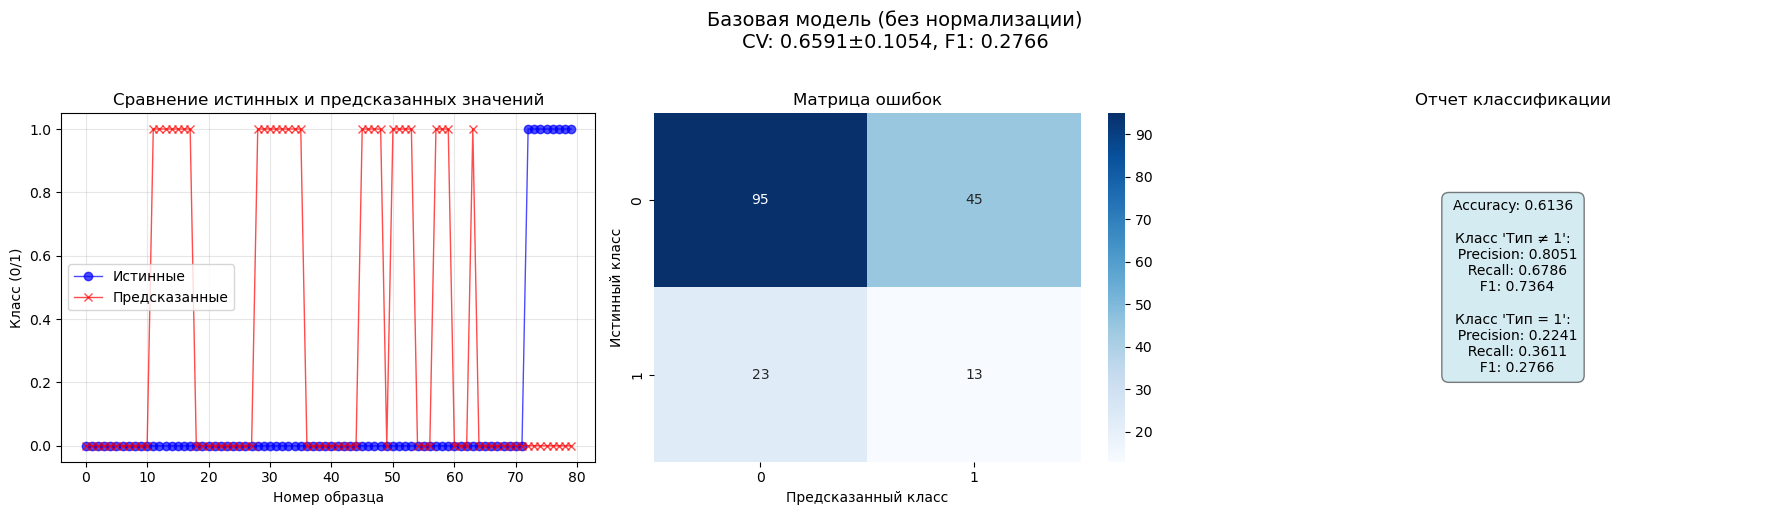

In [49]:
# ---------- БЛОК 3: БАЗОВАЯ МОДЕЛЬ БЕЗ ПРЕДОБРАБОТКИ ----------
if X_v1 is not None and y_v1 is not None:
    print("\n" + "="*70)
    print("БЛОК 3: БАЗОВАЯ МОДЕЛЬ (БЕЗ ПРЕДОБРАБОТКИ) - ПРИЗНАКИ V1")
    print("="*70)

    # Создание и оценка базовой модели
    base_model = MLPClassifier(
        hidden_layer_sizes=(50, 25),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        verbose=False
    )

    print("Оценка базовой модели без нормализации...")
    results_base = evaluate_model(X_v1, y_v1, base_model, cv=4)

    print(f"\nРезультаты базовой модели:")
    print(f"  CV (кросс-валидация): {results_base['cv_mean']:.4f} ± {results_base['cv_std']:.4f}")
    print(f"  Accuracy: {results_base['accuracy']:.4f}")
    print(f"  F1-score: {results_base['f1']:.4f}")

    # Визуализация результатов базовой модели
    plot_training_results(
        y_v1, 
        results_base['y_pred'],
        title="Базовая модель (без нормализации)",
        model_info=f"CV: {results_base['cv_mean']:.4f}±{results_base['cv_std']:.4f}, F1: {results_base['f1']:.4f}"
    )
else:
    print("Пропускаем Блок 3 - нет данных для работы")


БЛОК 3: БАЗОВАЯ МОДЕЛЬ (БЕЗ ПРЕДОБРАБОТКИ)
Оценка базовой модели без нормализации...

Результаты базовой модели:
  CV (кросс-валидация): 0.7557 ± 0.0670
  Accuracy: 0.7898
  F1-score: 0.0513


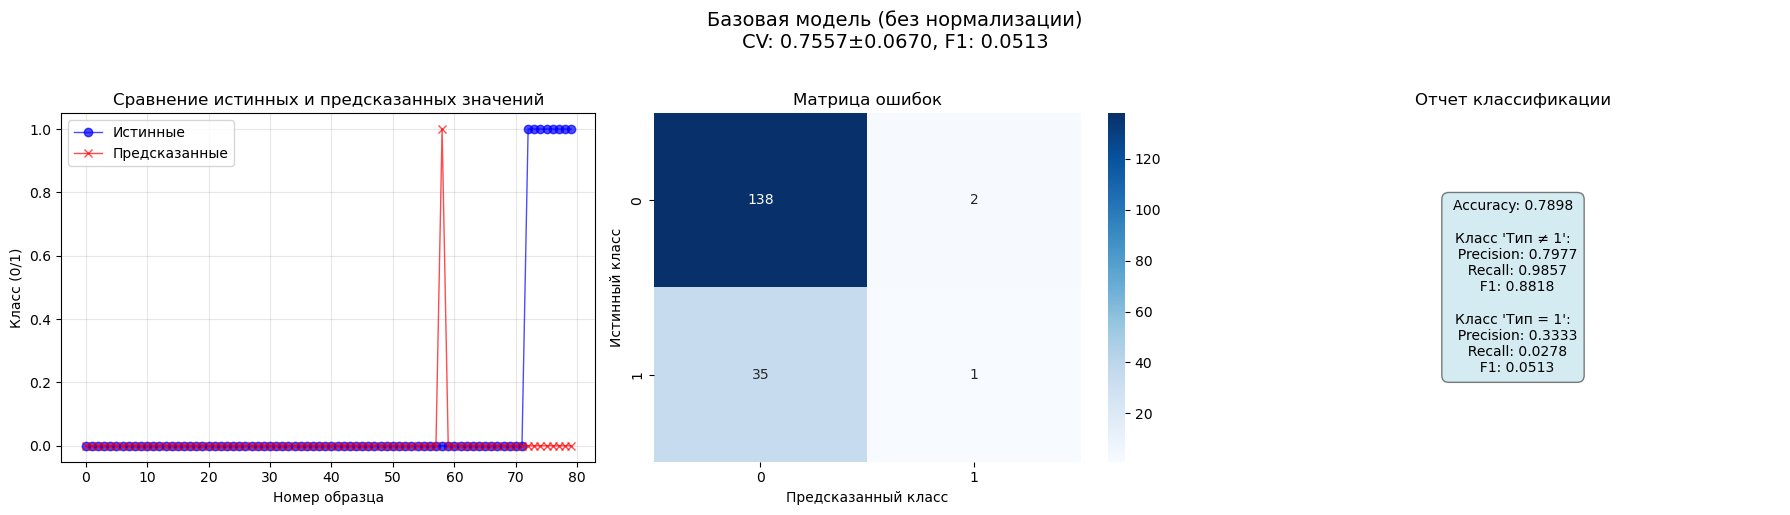

In [50]:
# ---------- БЛОК 3: БАЗОВАЯ МОДЕЛЬ БЕЗ ПРЕДОБРАБОТКИ ----------
if X is not None and y is not None:
    print("\n" + "="*70)
    print("БЛОК 3: БАЗОВАЯ МОДЕЛЬ (БЕЗ ПРЕДОБРАБОТКИ)")
    print("="*70)

    # Создание и оценка базовой модели
    base_model = MLPClassifier(
        hidden_layer_sizes=(50, 25),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        verbose=False
    )

    print("Оценка базовой модели без нормализации...")
    results_base = evaluate_model(X, y, base_model, cv=4)

    print(f"\nРезультаты базовой модели:")
    print(f"  CV (кросс-валидация): {results_base['cv_mean']:.4f} ± {results_base['cv_std']:.4f}")
    print(f"  Accuracy: {results_base['accuracy']:.4f}")
    print(f"  F1-score: {results_base['f1']:.4f}")

    # Визуализация результатов базовой модели
    plot_training_results(
        y, 
        results_base['y_pred'],
        title="Базовая модель (без нормализации)",
        model_info=f"CV: {results_base['cv_mean']:.4f}±{results_base['cv_std']:.4f}, F1: {results_base['f1']:.4f}"
    )
else:
    print("Пропускаем Блок 3 - нет данных для работы")

In [51]:
print(y_v1.value_counts)
print(y_v2.value_counts)
print(y_v1v2.value_counts)

<bound method IndexOpsMixin.value_counts of 0      0
1      0
2      0
3      0
4      0
      ..
171    1
172    1
173    1
174    1
175    1
Name: Type, Length: 176, dtype: int32>
<bound method IndexOpsMixin.value_counts of 0      0
1      0
2      0
3      0
4      0
      ..
171    1
172    1
173    1
174    1
175    1
Name: Type, Length: 176, dtype: int32>
<bound method IndexOpsMixin.value_counts of 0      0
1      0
2      0
3      0
4      0
      ..
171    1
172    1
173    1
174    1
175    1
Name: Type, Length: 176, dtype: int32>
